Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 50, 1)          │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - loss: 0.1659 - val_loss: 0.0320
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0453 - val_loss: 0.0284
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0350 - val_loss: 0.0238
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0319 - val_loss: 0.0219
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0282 - val_loss: 0.0175
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0235 - val_loss: 0.0149
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0217 - val_loss: 0.0146
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0318 - val_loss: 0.0201
Epoch 9/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0278 - val_loss: 0.0188
Epoch 10/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0262 - val_loss: 0.0173
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step


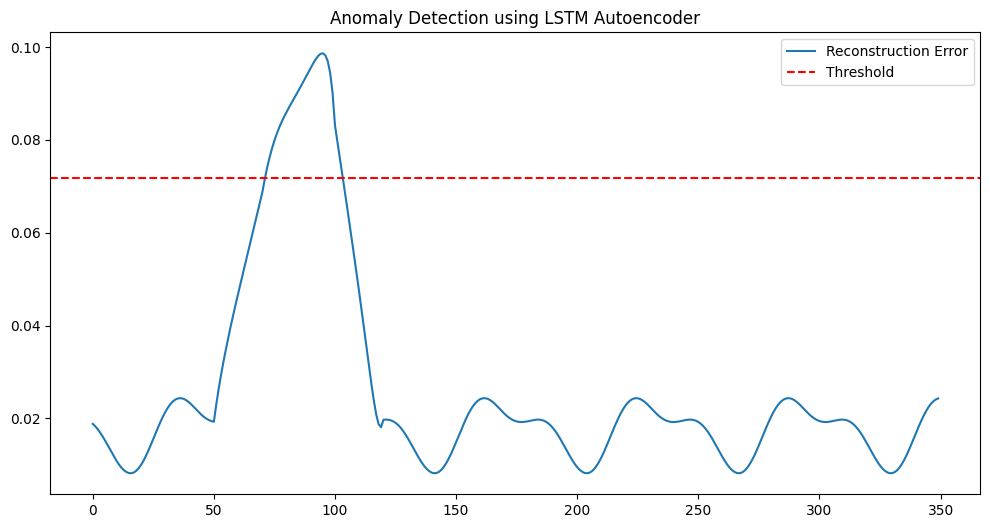

Number of anomalies detected: 32


In [ ]:
# ============================================================
# LSTM AUTOENCODER FOR ANOMALY DETECTION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from sklearn.preprocessing import MinMaxScaler

# -----------------------------
# STEP 1: Create Sample Data
# -----------------------------
# Normal data (sine wave)
timesteps = 50
samples = 1000

t = np.linspace(0, 100, samples)
data = np.sin(t)

# Add anomalies
data[200:220] = 3   # spike anomaly
data[700:720] = -3  # negative spike

# Normalize
scaler = MinMaxScaler()
data = scaler.fit_transform(data.reshape(-1, 1))

# -----------------------------
# STEP 2: Create sequences
# -----------------------------
def create_sequences(data, time_steps):
    sequences = []
    for i in range(len(data) - time_steps):
        sequences.append(data[i:i + time_steps])
    return np.array(sequences)

X = create_sequences(data, timesteps)

# Split train (only normal data)
X_train = X[:600]
X_test = X[600:]

# -----------------------------
# STEP 3: Build LSTM Autoencoder
# -----------------------------
inputs = Input(shape=(timesteps, 1))

encoded = LSTM(64, activation='relu')(inputs)
decoded = RepeatVector(timesteps)(encoded)
decoded = LSTM(64, activation='relu', return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(1))(decoded)

model = Model(inputs, decoded)
model.compile(optimizer='adam', loss='mse')

model.summary()

# -----------------------------
# STEP 4: Train Model
# -----------------------------
history = model.fit(
    X_train, X_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# -----------------------------
# STEP 5: Reconstruction
# -----------------------------
X_pred = model.predict(X_test)

# Compute reconstruction error
mse = np.mean(np.power(X_test - X_pred, 2), axis=(1,2))

# Threshold
threshold = np.mean(mse) + 2*np.std(mse)

# Detect anomalies
anomalies = mse > threshold

# -----------------------------
# STEP 6: Plot Results
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(mse, label='Reconstruction Error')
plt.axhline(threshold, color='r', linestyle='--', label='Threshold')
plt.legend()
plt.title("Anomaly Detection using LSTM Autoencoder")
plt.show()

print("Number of anomalies detected:", np.sum(anomalies))